In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display configurations
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)

print("Libraries successfully imported!")

Libraries successfully imported!


In [2]:
# Load dataset from data directory
df = pd.read_csv('../data/student_performance.csv')

print("=== DATASET OVERVIEW ===")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print("\nFirst 5 Rows:")
df.head()

=== DATASET OVERVIEW ===
Total Rows: 5
Total Columns: 7

First 5 Rows:


,student_id,study_hours,attendance,previous_score,city,internet_access,final_score
0,S001,4.5,87,72,Lahore,Yes,81
1,S002,6.0,92,85,lahore,Yes,90
2,S003,NaN,80,60,Karachi,No,58
3,S004,2.0,60,40,Islamabad,Yes,45
4,S005,8.0,95,98,Lahore,Yes,95


In [3]:
# Detailed summary table
data_summary = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.notnull().sum(),
    'Missing Count': df.isna().sum(),
    'Missing %': (df.isna().mean() * 100).round(2),
    'Unique Values': df.nunique()
})

print("=== COLUMN QUALITY METRICS ===")
print(data_summary)

print(f"\nExact Duplicate Rows: {df.duplicated().sum()}")

=== COLUMN QUALITY METRICS ===
                Data Type  Non-Null Count  Missing Count  Missing %  \
student_id            str               5              0        0.0   
study_hours       float64               4              1       20.0   
attendance          int64               5              0        0.0   
previous_score      int64               5              0        0.0   
city                  str               5              0        0.0   
internet_access       str               5              0        0.0   
final_score         int64               5              0        0.0   

                 Unique Values  
student_id                   5  
study_hours                  4  
attendance                   5  
previous_score               5  
city                         4  
internet_access              2  
final_score                  5  

Exact Duplicate Rows: 0


In [5]:
print("=== NUMERIC FEATURE SUMMARY ===")
print(df.describe().T)

print("\n=== IQR OUTLIER DETECTION ===")
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    print(f"Feature '{col}': {len(outliers)} outlier(s) detected outside [{lower_bound:.2f}, {upper_bound:.2f}]")

=== NUMERIC FEATURE SUMMARY ===
                count    mean        std   min     25%    50%   75%   max
study_hours       4.0   5.125   2.528998   2.0   3.875   5.25   6.5   8.0
attendance        5.0  82.800  13.953494  60.0  80.000  87.00  92.0  95.0
previous_score    5.0  71.000  22.405357  40.0  60.000  72.00  85.0  98.0
final_score       5.0  73.800  21.463923  45.0  58.000  81.00  90.0  95.0

=== IQR OUTLIER DETECTION ===
Feature 'study_hours': 0 outlier(s) detected outside [-0.06, 10.44]
Feature 'attendance': 1 outlier(s) detected outside [62.00, 110.00]
Feature 'previous_score': 0 outlier(s) detected outside [22.50, 122.50]
Feature 'final_score': 0 outlier(s) detected outside [10.00, 138.00]


In [6]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns

print("=== CATEGORICAL VALUE DISTRIBUTIONS ===")
for col in cat_cols:
    print(f"\n--- Column: {col} ---")
    print(df[col].value_counts(dropna=False))

=== CATEGORICAL VALUE DISTRIBUTIONS ===

--- Column: student_id ---
student_id
S001    1
S002    1
S003    1
S004    1
S005    1
Name: count, dtype: int64

--- Column: city ---
city
Lahore       2
lahore       1
Karachi      1
Islamabad    1
Name: count, dtype: int64

--- Column: internet_access ---
internet_access
Yes    4
No     1
Name: count, dtype: int64


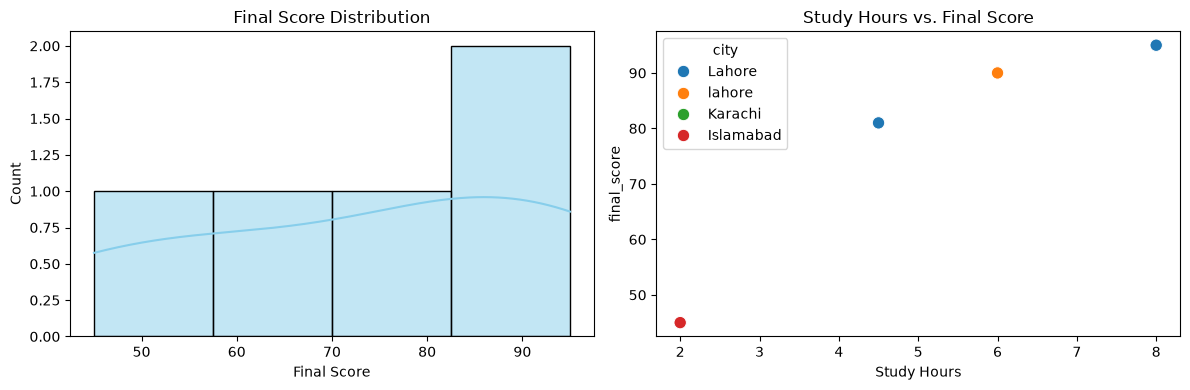

In [4]:
plt.figure(figsize=(12, 4))

# Target Variable Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['final_score'].dropna(), kde=True, color='skyblue')
plt.title('Final Score Distribution')
plt.xlabel('Final Score')

# Feature vs Target Relationship
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='study_hours', y='final_score', hue='city', s=80)
plt.title('Study Hours vs. Final Score')
plt.xlabel('Study Hours')

plt.tight_layout()
plt.show()